# Libraries

In [56]:
from pandas import read_csv, unique

import numpy as np

from scipy.interpolate import interp1d
from scipy.stats import mode

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report

from tensorflow import stack
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, GlobalAveragePooling1D, BatchNormalization, MaxPooling1D, Reshape, Activation, Dropout, Flatten
from keras.layers import Conv1D, LSTM
from keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

# df = read_data('../input/humanactivityrecognitiondataset/WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt')


In [57]:
def read_data(filepath):
    df = read_csv(filepath, header=None, names=['user-id',
                                               'activity',
                                               'timestamp',
                                               'X',
                                               'Y',
                                               'Z'], on_bad_lines = 'skip')
    ## removing ';' from last column and converting it to float
    df['Z'].replace(regex=True, inplace=True, to_replace=r';', value=r'')
    df['Z'] = df['Z'].apply(convert_to_float)
#     df.dropna(axis=0, how='any', inplace=True)
    return df

def convert_to_float(x):
    try:
        return np.float64(x)
    except:
        return np.nan

In [58]:
df = read_data('../input/humanactivityrecognitiondataset/WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt')
df

,user-id,activity,timestamp,X,Y,Z
0,33,Jogging,49105962326000,-0.694638,12.680544,0.503953
1,33,Jogging,49106062271000,5.012288,11.264028,0.953424
2,33,Jogging,49106112167000,4.903325,10.882658,-0.081722
3,33,Jogging,49106222305000,-0.612916,18.496431,3.023717
4,33,Jogging,49106332290000,-1.184970,12.108489,7.205164
...,...,...,...,...,...,...
1086461,19,Sitting,131623331483000,9.000000,-1.570000,1.690000
1086462,19,Sitting,131623371431000,9.040000,-1.460000,1.730000
1086463,19,Sitting,131623411592000,9.080000,-1.380000,1.690000
1086464,19,Sitting,131623491487000,9.000000,-1.460000,1.730000


# Label Encoder

In [59]:
label_encode = LabelEncoder()
df['activityEncode'] = label_encode.fit_transform(df['activity'].values.ravel())
df

,user-id,activity,timestamp,X,Y,Z,activityEncode
0,33,Jogging,49105962326000,-0.694638,12.680544,0.503953,1
1,33,Jogging,49106062271000,5.012288,11.264028,0.953424,1
2,33,Jogging,49106112167000,4.903325,10.882658,-0.081722,1
3,33,Jogging,49106222305000,-0.612916,18.496431,3.023717,1
4,33,Jogging,49106332290000,-1.184970,12.108489,7.205164,1
...,...,...,...,...,...,...,...
1086461,19,Sitting,131623331483000,9.000000,-1.570000,1.690000,2
1086462,19,Sitting,131623371431000,9.040000,-1.460000,1.730000,2
1086463,19,Sitting,131623411592000,9.080000,-1.380000,1.690000,2
1086464,19,Sitting,131623491487000,9.000000,-1.460000,1.730000,2


In [87]:
# scaler = StandardScaler()
# df[['X', 'Y', 'Z']] = scaler.fit_transform(df[['X', 'Y', 'Z']])

In [60]:
interpolation_fn = interp1d(df['activityEncode'] ,df['Z'], kind='linear')
interpolation_fn

In [61]:
null_list = df[df['Z'].isnull()].index.tolist()
null_list

[343413]

In [62]:
for i in null_list:
    y = df['activityEncode'][i]
    value = interpolation_fn(y)
    df['Z']=df['Z'].fillna(value)
    print(value)

4.75


In [63]:
## train split users between 1 and 27, test split users between 28 and 33
df_test = df[df['user-id'] > 27]
df_train = df[df['user-id'] <= 27]

In [64]:
df_train['X'] = (df_train['X']-df_train['X'].min())/(df_train['X'].max()-df_train['X'].min())
df_train['Y'] = (df_train['Y']-df_train['Y'].min())/(df_train['Y'].max()-df_train['Y'].min())
df_train['Z'] = (df_train['Z']-df_train['Z'].min())/(df_train['Z'].max()-df_train['Z'].min())
df_train

,user-id,activity,timestamp,X,Y,Z,activityEncode
8489,17,Walking,57869902574000,0.510163,0.741908,0.488932,5
8490,17,Walking,57870012316000,0.495703,0.751526,0.487895,5
8491,17,Walking,57870122301000,0.489850,0.742938,0.484785,5
8492,17,Walking,57870222246000,0.499490,0.748778,0.489623,5
8493,17,Walking,57870332292000,0.499490,0.750496,0.486858,5
...,...,...,...,...,...,...,...
1086461,19,Sitting,131623331483000,0.723205,0.454981,0.545293,2
1086462,19,Sitting,131623371431000,0.724216,0.457755,0.546308,2
1086463,19,Sitting,131623411592000,0.725228,0.459773,0.545293,2
1086464,19,Sitting,131623491487000,0.723205,0.457755,0.546308,2


In [65]:
df_train['activityEncode'].value_counts()

activityEncode
5    308337
1    256920
4     90906
0     71434
2     41932
3     32157
Name: count, dtype: int64

In [66]:
# def segments(df, time_steps, step, label_name):
#     N_FEATURES = 3
#     segments = []
#     labels = []
#     for i in range(0, len(df) - time_steps, step):
#         xs = df['X'].values[i:i+time_steps]
#         ys = df['Y'].values[i:i+time_steps]
#         zs = df['Z'].values[i:i+time_steps]
        
#         label = mode(df[label_name][i:i+time_steps])[0][0]
#         segments.append([xs, ys, zs])
#         labels.append(label)
    
#     reshaped_segments = np.asarray(segments, dtype=np.float32).reshape(-1, time_steps, N_FEATURES)
#     labels = np.asarray(labels)
    
#     return reshaped_segments, labels
# from scipy.stats import mode

def segments(df, time_steps, step, label_name):
    segments = []
    labels = []
    
    for i in range(0, len(df) - time_steps, step):
        # Extract time window
        xs = df['X'].values[i:i+time_steps]
        ys = df['Y'].values[i:i+time_steps]
        zs = df['Z'].values[i:i+time_steps]
        
        # Correctly extract the mode of the labels
        label = mode(df[label_name][i:i+time_steps], keepdims=True).mode[0]
        
        # Append the segments and labels
        segments.append([xs, ys, zs])
        labels.append(label)
    
    # Convert to numpy arrays and transpose
    X = np.array(segments).transpose(0, 2, 1)  # Shape: (num_samples, time_steps, 3)
    y = np.array(labels)
    return X, y


In [67]:
# TIME_PERIOD = 80
# STEP_DISTANCE = 40
# LABEL = 'activityEncode'
# x_train, y_train = segments(df_train, TIME_PERIOD, STEP_DISTANCE, LABEL)
TIME_PERIOD = 80
STEP_DISTANCE = 40
LABEL = 'activityEncode'

try:
    x_train, y_train = segments(df_train, TIME_PERIOD, STEP_DISTANCE, LABEL)
    print("Segmented Data Shape:", x_train.shape)  # Expected: (num_samples, TIME_PERIOD, 3)
    print("Labels Shape:", y_train.shape)          # Expected: (num_samples,)
except Exception as e:
    print("Error:", e)


Segmented Data Shape: (20041, 80, 3)
Labels Shape: (20041,)


In [69]:
## Input and Output Dimensions
time_period, sensors = x_train.shape[1], x_train.shape[2]
num_classes = label_encode.classes_.size
print(list(label_encode.classes_))

['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs', 'Walking']


In [70]:
## reshaping data
input_shape = time_period * sensors
x_train = x_train.reshape(x_train.shape[0], input_shape)

print("Input Shape: ", input_shape)
print("Input Data Shape: ", x_train.shape)

Input Shape:  240
Input Data Shape:  (20041, 240)


In [71]:
x_train = x_train.astype('float32')
y_train = y_train.astype('float32')
print(x_train.shape)
print(y_train.shape)

(20041, 240)
(20041,)


In [72]:
y_train_hot = to_categorical(y_train, num_classes)
print("y_train shape: ", y_train_hot.shape)

y_train shape:  (20041, 6)


In [53]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_train_flat = x_train.reshape((x_train.shape[0], -1))  # Flatten for SMOTE
x_train_balanced, y_train_balanced = smote.fit_resample(x_train_flat, y_train)

# Reshape back for LSTM input
x_train_balanced = x_train_balanced.reshape(-1, 240, 3)
print(x_train_balanced.shape)
print(x_train.shape)


(18258, 240, 3)
(6680, 240, 3)


In [73]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Bidirectional, Conv1D, MaxPool1D, Dense, Flatten, Dropout, BatchNormalization

# # Define the model
# model = Sequential()

# # Input LSTM Layer
# model.add(Bidirectional(LSTM(64, return_sequences=True, activation='tanh'), input_shape=(240, 3)))
# model.add(Dropout(0.2))  # Regularization

# # Conv1D Layer for Feature Extraction
# model.add(Conv1D(filters=64, kernel_size=3, activation='relu', strides=1, padding='same'))
# model.add(BatchNormalization())  # Normalize activations
# model.add(MaxPool1D(pool_size=2, padding='same'))  # Downsample

# # Additional LSTM Layer
# model.add(Bidirectional(LSTM(128, return_sequences=True, activation='tanh')))
# model.add(Dropout(0.3))

# # Another Conv1D Layer
# model.add(Conv1D(filters=128, kernel_size=5, activation='relu', strides=1, padding='same'))
# model.add(BatchNormalization())
# model.add(MaxPool1D(pool_size=2, padding='same'))

# # Flatten Layer
# model.add(Flatten())

# # Fully Connected Layers
# model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.4))  # Higher dropout for dense layer

# model.add(Dense(64, activation='relu'))
# model.add(Dropout(0.3))

# # Output Layer
# model.add(Dense(6, activation='softmax'))  # Adjust for number of classes

# # Compile the Model
# from tensorflow.keras.optimizers import Adam

# optimizer = Adam(learning_rate=0.0005)  # Small learning rate
# model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# # Model Summary
# model.summary()

# # Update the model to match the correct number of output units (7 for 7 classes)
# model = Sequential()

# # CNN layer for feature extraction
# model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_normalized.shape[1], 1)))
# model.add(MaxPooling1D(pool_size=2))
# model.add(Dropout(0.2))

# # Another CNN layer for deeper feature extraction
# model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
# model.add(MaxPooling1D(pool_size=2))
# model.add(Dropout(0.2))

# # LSTM layer for sequence learning
# model.add(LSTM(units=100, return_sequences=False))
# model.add(Dropout(0.2))

# # Dense layers for classification
# model.add(Dense(64, activation='relu'))

# # Adjust the final layer to match the number of classes
# model.add(Dense(num_classes, activation='softmax'))  # Make sure the number of classes matches the labels

# # Compile the model
# model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Build the model
model = Sequential()

# CNN layer for feature extraction
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(x_train.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.2))

# model.add(LSTM(64, return_sequences=True))
# model.add(Flatten())
# model.add(Dense(6, activation='softmax'))  # Example: 6 output classes

# Another CNN layer for deeper feature extraction
model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.2))

# LSTM layer for sequence learning
model.add(LSTM(units=100, return_sequences=False))
model.add(Dropout(0.2))

# Dense layers for classification
model.add(Dense(64, activation='relu'))

# Output layer with 6 classes
model.add(Dense(6, activation='softmax'))  # 6 classes
model.summary()

# Compile the model
# model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_13 (Conv1D)              │ (None, 238, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 119, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 119, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 117, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 58, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 58, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 100)            │        91,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,414 (482.09 KB)

 Trainable params: 123,414 (482.09 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
# model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
optimizer = Adam()  # Small learning rate
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [75]:
import numpy as np

# Debug current shape
# total_elements = np.array(x_train).size
# print("Total elements:", total_elements)

# # Trim to the largest multiple of 720
# usable_elements = (total_elements // 720) * 720
# print("Usable elements:", usable_elements)

# # Flatten and trim
# x_train_trimmed = np.array(x_train).flatten()[:usable_elements]

# # Reshape into (samples, 240, 3)
# samples = usable_elements // (240 * 3)
# x_train = x_train_trimmed.reshape(samples, 240, 3)

print("x_train new shape:", x_train.shape)  # Expected: (samples, 240, 3)

min_samples = min(x_train.shape[0], y_train.shape[0])
x_train = x_train[:min_samples]
y_train = y_train[:min_samples]

print(y_train_hot.shape)
print(y_train.shape)

x_train new shape: (20041, 240)
(20041, 6)
(20041,)


In [82]:
# from tensorflow.keras.callbacks import EarlyStopping

# # Early stopping to avoid overfitting
# early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# # Reshape the input data to 3D (samples, time_steps, features)
# # x_train = x_train.reshape(-1, 240, 3)  # Ensure correct shape
# # x_test = x_test.reshape(-1, 240, 3)


# # Train the model
# history = model.fit(x_train, 
#                     y_train, 
#                     batch_size=128, 
#                     epochs=15, 
#                     validation_split = 0.2,
#                     callbacks=[early_stop])

# EarlyStopping callback to stop training when validation loss stops improving
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# # Train the model with EarlyStopping

# history = model.fit(
#     x_train, y_train_hot,
#     epochs=15,  # Start with a large number of epochs
#     batch_size=64,
#     validation_split = 0.2,
#     callbacks=[early_stopping]
# )
# import numpy as np

# Convert one-hot encoded labels to integer labels
y_train_sparse = np.argmax(y_train_hot, axis=1)

print("y_train_sparse shape:", y_train_sparse.shape)  # Should be (samples,)
print("Example labels:", y_train_sparse[:10])  # Integer class labels

# Use sparse_categorical_crossentropy
# Train the model with sparse labels
history = model.fit(
    x_train, y_train_sparse,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping]
)

# # Evaluate the model on test data
# y_pred = model.predict(X_test_scaled)
# y_pred_classes = np.argmax(y_pred, axis=1)
# y_true = np.argmax(y_test_one_hot, axis=1)


y_train_sparse shape: (20041,)
Example labels: [5 5 5 5 5 5 5 5 5 5]
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 28s 102ms/step - accuracy: 0.4520 - loss: 1.3869 - val_accuracy: 0.6204 - val_loss: 1.0650
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 26s 103ms/step - accuracy: 0.6990 - loss: 0.7941 - val_accuracy: 0.3829 - val_loss: 1.6183
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 41s 101ms/step - accuracy: 0.7504 - loss: 0.6675 - val_accuracy: 0.5196 - val_loss: 1.6107
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 26s 103ms/step - accuracy: 0.7651 - loss: 0.6366 - val_accuracy: 0.7094 - val_loss: 0.7977
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 26s 102ms/step - accuracy: 0.7921 - loss: 0.5647 - val_accuracy: 0.7022 - val_loss: 0.7760
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 26s 102ms/step - accuracy: 0.7941 - loss: 0.5547 - val_accuracy: 0.7531 - val_loss: 0.7063
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 41s 101ms/step - accuracy: 0.7979 - loss: 0.5384 - val_accuracy: 0.6533 - val_loss: 0.8988
Epoch 8/15
251

NameError: name 'X_test_scaled' is not defined

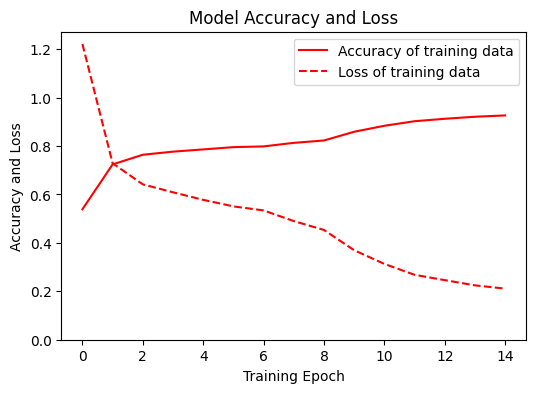

627/627 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step
              precision    recall  f1-score   support

         0.0       0.74      0.84      0.79      1791
         1.0       0.98      0.94      0.96      6424
         2.0       0.98      0.88      0.93      1049
         3.0       0.86      0.99      0.92       802
         4.0       0.78      0.79      0.78      2269
         5.0       0.97      0.96      0.96      7706

    accuracy                           0.92     20041
   macro avg       0.88      0.90      0.89     20041
weighted avg       0.93      0.92      0.92     20041



In [83]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], 'r', label='Accuracy of training data')
plt.plot(history.history['loss'], 'r--', label='Loss of training data')
plt.title('Model Accuracy and Loss')
plt.ylabel('Accuracy and Loss')
plt.xlabel('Training Epoch')
plt.ylim(0)
plt.legend()
plt.show()

y_pred_train = model.predict(x_train)
max_y_pred_train = np.argmax(y_pred_train, axis=1)

# Align labels
y_train_aligned = y_train[:max_y_pred_train.shape[0]]

# Classification report
from sklearn.metrics import classification_report
print(classification_report(y_train_aligned, max_y_pred_train))